<a href="https://colab.research.google.com/github/JorgePeje/test-python-utec/blob/main/lecturadatapack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# =========================
# 1. CARGAR ARCHIVO
# =========================
from google.colab import files
uploaded = files.upload()

import pandas as pd
from io import StringIO

archivo = list(uploaded.keys())[0]

# =========================
# 2. LEER COMO TEXTO
# =========================
with open(archivo, 'r', encoding='latin1') as f:
    lineas = f.readlines()

# =========================
# 3. ENCONTRAR HEADER
# =========================
for i, linea in enumerate(lineas):
    if "Date Time" in linea and "Time" in linea:
        header_index = i
        break

print("Header en fila:", header_index)

# =========================
# 4. SEPARAR HEADER Y DATA
# =========================
header = lineas[header_index].strip()
data = lineas[header_index + 1:]

# =========================
# 5. ARMAR DATAFRAME
# =========================
df = pd.read_csv(
    StringIO(header + "\n" + "".join(data)),
    engine="python"
)

df["Time"] = pd.to_numeric(df["Time"], errors='coerce')

# Filtrar solo datos reales del evento
df = df[(df["Time"] > -10) & (df["Time"] < 10)]

df = df.sort_values("Time").reset_index(drop=True)

print(df["Time"].min(), df["Time"].max())
print("Filas:", len(df))

# =========================
# 7. CONVERTIR RESTO DE COLUMNAS
# =========================
for col in df.columns:
    if col != "Date Time":
        df[col] = pd.to_numeric(df[col], errors='coerce')

Saving dp_M613_T3162_20260314-131517.183_31-3.csv to dp_M613_T3162_20260314-131517.183_31-3 (4).csv
Header en fila: 52
-4.404 1.546
Filas: 120


In [24]:
# =========================
# 6. LIMPIEZA REAL (CLAVE)
# =========================

# Convertir Time correctamente
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')

# Eliminar filas inválidas (IDs, basura, etc.)
df = df[df["Time"].notna()]

# Reset index
df = df.reset_index(drop=True)

print(df.head())
print("Filas:", len(df))

                 Date Time   Time  run_inverter_actual_1  \
0  2026-03-14 13:15:12.780 -4.404                      0   
1  2026-03-14 13:15:12.830 -4.354                      0   
2  2026-03-14 13:15:12.880 -4.304                      0   
3  2026-03-14 13:15:12.930 -4.254                      0   
4  2026-03-14 13:15:12.980 -4.204                      0   

   run_inverter_actual_2  inv_modes_1  inv_modes_2  state  \
0                      0            2            2      2   
1                      0            2            2      2   
2                      0            2            2      2   
3                      0            2            2      2   
4                      0            2            2      2   

   psc_inv1_pwrup_tst_ss  psc_inv2_pwrup_tst_ss  psc_selected_direction  ...  \
0                      2                      2                       0  ...   
1                      2                      2                       0  ...   
2                      2        

In [25]:

# =========================
# 7. ORDENAR Y VALIDAR TIEMPO
# =========================

# Convertir Time a numérico (segundos antes/después del evento)
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')

# Ordenar por tiempo
df = df.sort_values(by="Time")

print(df)
# =========================

                   Date Time   Time  run_inverter_actual_1  \
0    2026-03-14 13:15:12.780 -4.404                      0   
1    2026-03-14 13:15:12.830 -4.354                      0   
2    2026-03-14 13:15:12.880 -4.304                      0   
3    2026-03-14 13:15:12.930 -4.254                      0   
4    2026-03-14 13:15:12.980 -4.204                      0   
..                       ...    ...                    ...   
115  2026-03-14 13:15:18.530  1.346                      0   
116  2026-03-14 13:15:18.580  1.396                      0   
117  2026-03-14 13:15:18.630  1.446                      0   
118  2026-03-14 13:15:18.680  1.496                      0   
119  2026-03-14 13:15:18.730  1.546                      0   

     run_inverter_actual_2  inv_modes_1  inv_modes_2  state  \
0                        0            2            2      2   
1                        0            2            2      2   
2                        0            2            2      2   
3  

In [26]:
# 8. FUNCION DE GRAFICAS
# =========================

import matplotlib.pyplot as plt

def graficar_parametros(df, parametros):
    plt.figure(figsize=(14,6))

    for param in parametros:
        if param in df.columns:
            plt.plot(df["Time"], df[param], label=param)
        else:
            print(f"⚠️ {param} no existe")

    # Línea en el evento (t = 0)
    plt.axvline(x=0, linestyle='--')

    plt.xlabel("Time (s)")
    plt.ylabel("Valor")
    plt.title("Evento - Análisis de Variables vs Tiempo")
    plt.legend()
    plt.grid()
    plt.show()




Variables disponibles:

['Date Time', 'Time', 'run_inverter_actual_1', 'run_inverter_actual_2', 'inv_modes_1', 'inv_modes_2', 'state', 'psc_inv1_pwrup_tst_ss', 'psc_inv2_pwrup_tst_ss', 'psc_selected_direction', 'ptu_psc_digin_packed_lo', 'ptu_psc_digin_packed_hi', 'ptu_tci_in_packed_lo', 'ptu_tci_in_packed_hi', 'ptu_tci_in2_packed_lo', 'ptu_tci_in2_packed_hi', 'ptu_tci_out2_packed_lo', 'ptu_tci_out2_packed_hi', 'ptu_tci_out1_packed_lo', 'ptu_tci_out1_packed_hi', 'ptu_bit_word', 'test_ss', 'link_ss', 'altfamps_ai7', 'linki_ai8', 'gridi_ai9', 'a3pvolt_ai10', 'altfvolt_ai11', 'linkv_ai12', 'engine_load_ptu', 'batt_volt_ai29', 'rsc_set_speed_mph', 'ambts', 'flwspeed_rpm', 'frwspeed_rpm', 'torque_fb_1', 'torque_fb_2', 'inv_link_volts_1', 'inv_link_volts_2', 'psc_inv1_speed_fb', 'psc_inv2_speed_fb', 'engspd_sm', 'common_ptu4', 'af_curr_ref_ao1', 'rpinhi_ai15', 'retlever_ai14', 'hp_call_sel', 'hp_fb_alt_input', 'truckspd', 'apinhi_sm', 'retard_in_sel', 'engrpmcmd_fo1', 'torque_cmd_inv1', 'to

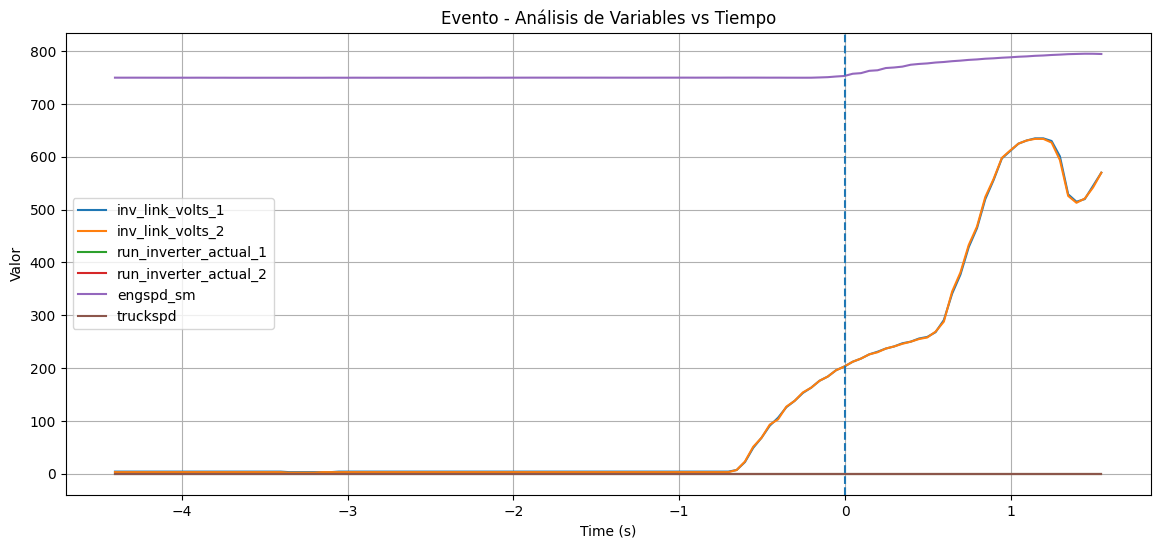

In [27]:
# =========================
# 9. MOSTRAR VARIABLES DISPONIBLES
# =========================

print("\nVariables disponibles:\n")
print(list(df.columns))

# =========================
# 10. SELECCION DE VARIABLES
# =========================

parametros = [
    "inv_link_volts_1",
    "inv_link_volts_2",
    "run_inverter_actual_1",
    "run_inverter_actual_2",
    "engspd_sm",
    "truckspd"
]

graficar_parametros(df, parametros)

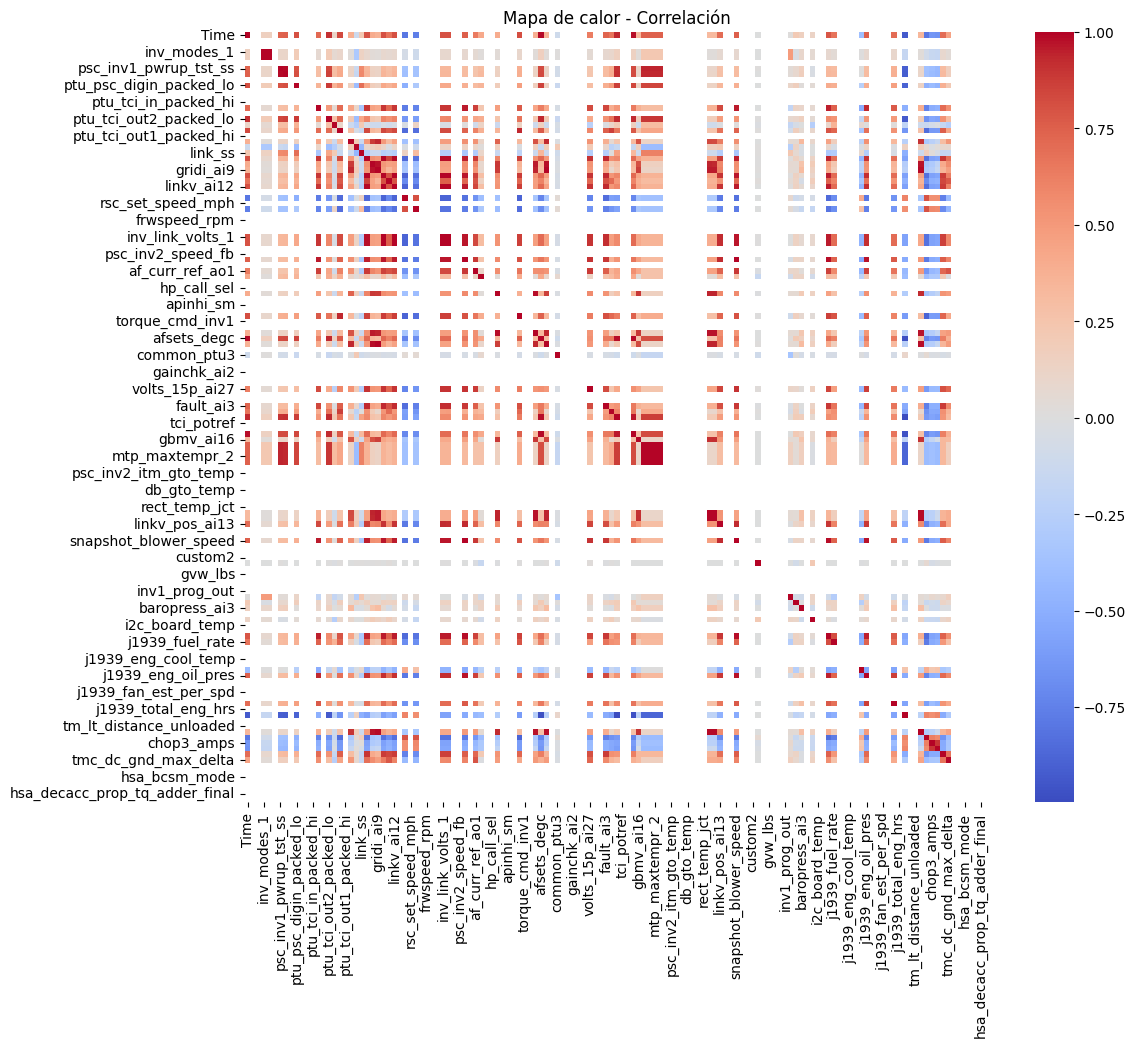

inv_link_volts_1  inv_link_volts_2    0.999977
inv_link_volts_2  inv_link_volts_1    0.999977
b2amps_abs        b1amps_abs          0.999966
b1amps_abs        b2amps_abs          0.999966
linkv_ai12        a3pvolt_ai10        0.997856
a3pvolt_ai10      linkv_ai12          0.997856
linkv_ai12        inv_link_volts_2    0.997799
inv_link_volts_2  linkv_ai12          0.997799
inv_link_volts_1  linkv_ai12          0.997448
linkv_ai12        inv_link_volts_1    0.997448
gridi_ai9         common_ptu1         0.997112
common_ptu1       gridi_ai9           0.997112
incline_percent   baropress           0.995942
baropress         incline_percent     0.995942
a3pvolt_ai10      inv_link_volts_2    0.995044
inv_link_volts_2  a3pvolt_ai10        0.995044
inv_link_volts_1  a3pvolt_ai10        0.994675
a3pvolt_ai10      inv_link_volts_1    0.994675
                  altfamps_ai7        0.994044
altfamps_ai7      a3pvolt_ai10        0.994044
dtype: float64


In [30]:
# =========================
# CORRELACIÓN
# =========================
import seaborn as sns

df_corr = df.select_dtypes(include=['float64', 'int64'])

corr = df_corr.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Mapa de calor - Correlación")
plt.show()

# =========================
# CORRELACIONES ALTAS
# =========================
corr_unstack = corr.abs().unstack()

# eliminar duplicados
corr_unstack = corr_unstack.sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]

print(corr_unstack.head(20))